# Student Performance (Multiple Linear Regression)

## Exploring Factors Affecting Student Performance

## Machine Learning Lifecycle

**The machine learning lifecycle is a process that guides the development and deployment of machine learning models in a structured way. It consists of various steps.**

- Problem Definition
- Data Collection
- Data Quality Check
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Model Training
- Choose Best Model

## 1. Problem Definition

- This project explores how the student's performance (Performance Index) is affected by the factors like Hours Studied, Previous Scores, Extracurricular Activities, Sleep Hours and Sample Question Papers Practiced.

## 2. Data Collection

- Dataset Source - [Link](https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression)
- The dataset consists of 10,000 student records.

### 2.1) Import Data & Libraries

**Importing Pandas, Numpy, Seaborn, MatplotLib and Warnings Library.**

In [1]:
import pandas as pd # chiefly used for machine learning in the form of DataFrames
import numpy as np # used for working with arrays
import seaborn as sns # used to create statistical graphics for data visualization
import matplotlib.pyplot as plt # used to create data visualizations, such as plots, histograms, bar charts, and scatter plots
%matplotlib inline 
# enables the rendering of Matplotlib plots directly below code cells

import warnings
warnings.filterwarnings('ignore') # for ignoring the warnings 

**Import CSV file in the form of Pandas Dataframe**

In [2]:
data = pd.read_csv('data/Student_Performance.csv')

**Top 5 Records**

In [3]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


**Shape of the Dataset**

In [4]:
data.shape

(10000, 6)

## 2.2) About Dataset

### Description:

The Student Performance Dataset is a dataset designed to examine the factors influencing academic student performance. The dataset consists of 10,000 student records, with each record containing information about various predictors and a performance index.

### Variables:

**Hours Studied:** The total number of hours spent studying by each student.

**Previous Scores:** The scores obtained by students in previous tests.

**Extracurricular Activities:** Whether the student participates in extracurricular activities (Yes or No).

**Sleep Hours:** The average number of hours of sleep the student had per day.

**Sample Question Papers Practiced:** The number of sample question papers the student practiced.

### Target Variable:

**Performance Index:** A measure of the overall performance of each student. The performance index represents the student's academic performance and has been rounded to the nearest integer. The index ranges from 10 to 100, with higher values indicating better performance.

## 3. Data Quality Check

- Check Missing values
- Check Data-types
- Check Duplicates
- Check unique values count of each variable.
- Check descriptive statistics of the dataset.

### 3.1) Check Missing values

In [5]:
data.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

**There are no missing-values in the dataset.**

### 3.2) Check Data-types

In [6]:
data.dtypes

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

**Numeric variables:** Hours Studied, Previous Scores, Sleep Hours, Sample Question Papers Practiced, Performance Index (Target)

**Categorical vaiables:** Extracurricular Activities

### 3.3) Check Duplicates

In [7]:
print('Duplicate records count:', data.duplicated().sum())

Duplicate records count: 127


**127 records are identified as duplicates, hence removing them can help to prevent the model from overfitting to the training data.**

### 3.4) Check unique values count of each variable.

In [8]:
print('Unique values count of each variable\n\n', data.nunique(), sep="")

Unique values count of each variable

Hours Studied                        9
Previous Scores                     60
Extracurricular Activities           2
Sleep Hours                          6
Sample Question Papers Practiced    10
Performance Index                   91
dtype: int64


**Extracurricular Activities variable signifies that a student is participating or not in it (Yes or No).**

### 3.5) Check descriptive statistics of the dataset.

In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours Studied,10000.0,4.9929,2.589309,1.0,3.0,5.0,7.0,9.0
Previous Scores,10000.0,69.4457,17.343152,40.0,54.0,69.0,85.0,99.0
Sleep Hours,10000.0,6.5306,1.695863,4.0,5.0,7.0,8.0,9.0
Sample Question Papers Practiced,10000.0,4.5833,2.867348,0.0,2.0,5.0,7.0,9.0
Performance Index,10000.0,55.2248,19.212558,10.0,40.0,55.0,71.0,100.0


In [10]:
print('Categories count of', data.select_dtypes('object').value_counts(), sep=" ")

Categories count of Extracurricular Activities
No                            5052
Yes                           4948
Name: count, dtype: int64


**Insights**

- All the numeric variables are discrete in nature.
- There is a huge difference between mean of Previous Scores and Performance Index.
- Also mean and median are almost equal or closely equal for all numeric variables.
- Minimum of Previous Scores is equal to the 25th percentile of Performance Index. This shows Performance Index are not as appreciable as compared to that of Previous scores of students.
- Extracurricular Activities categories are quite balanced (i.e., no class imbalance).

## 4. Exploratory Data Analysis

### 4.1 Uni-Variate Analysis

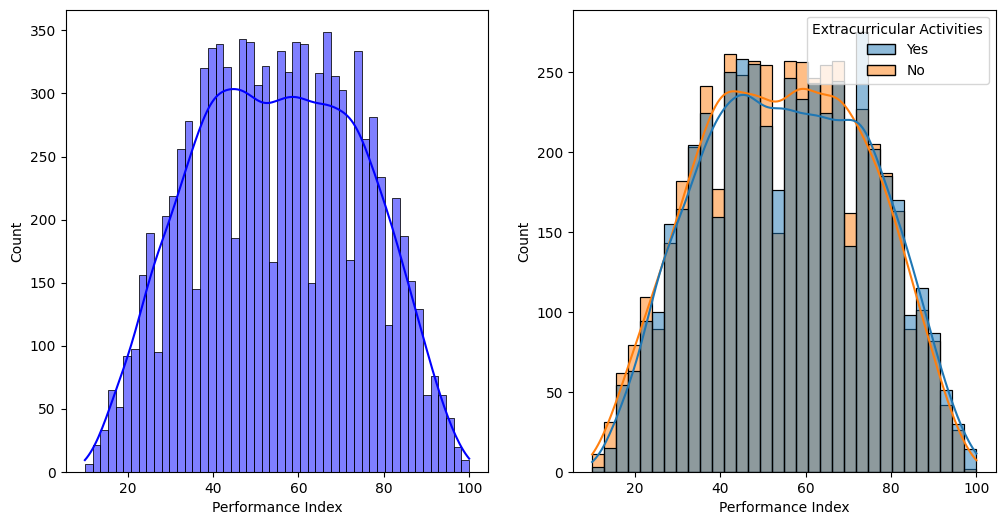

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12,6))
plt.subplot(121)
sns.histplot(data=data, x='Performance Index', kde=True, bins=50, color='b')
plt.subplot(122)
sns.histplot(data=data, x='Performance Index', kde=True, hue='Extracurricular Activities')
plt.show()

**Students that are indulged in the Extra-curricular activities are more for the Performance Index values greater than 75 as compared to students that are not participating in them.**

### 4.2 Bi-Variate Analysis

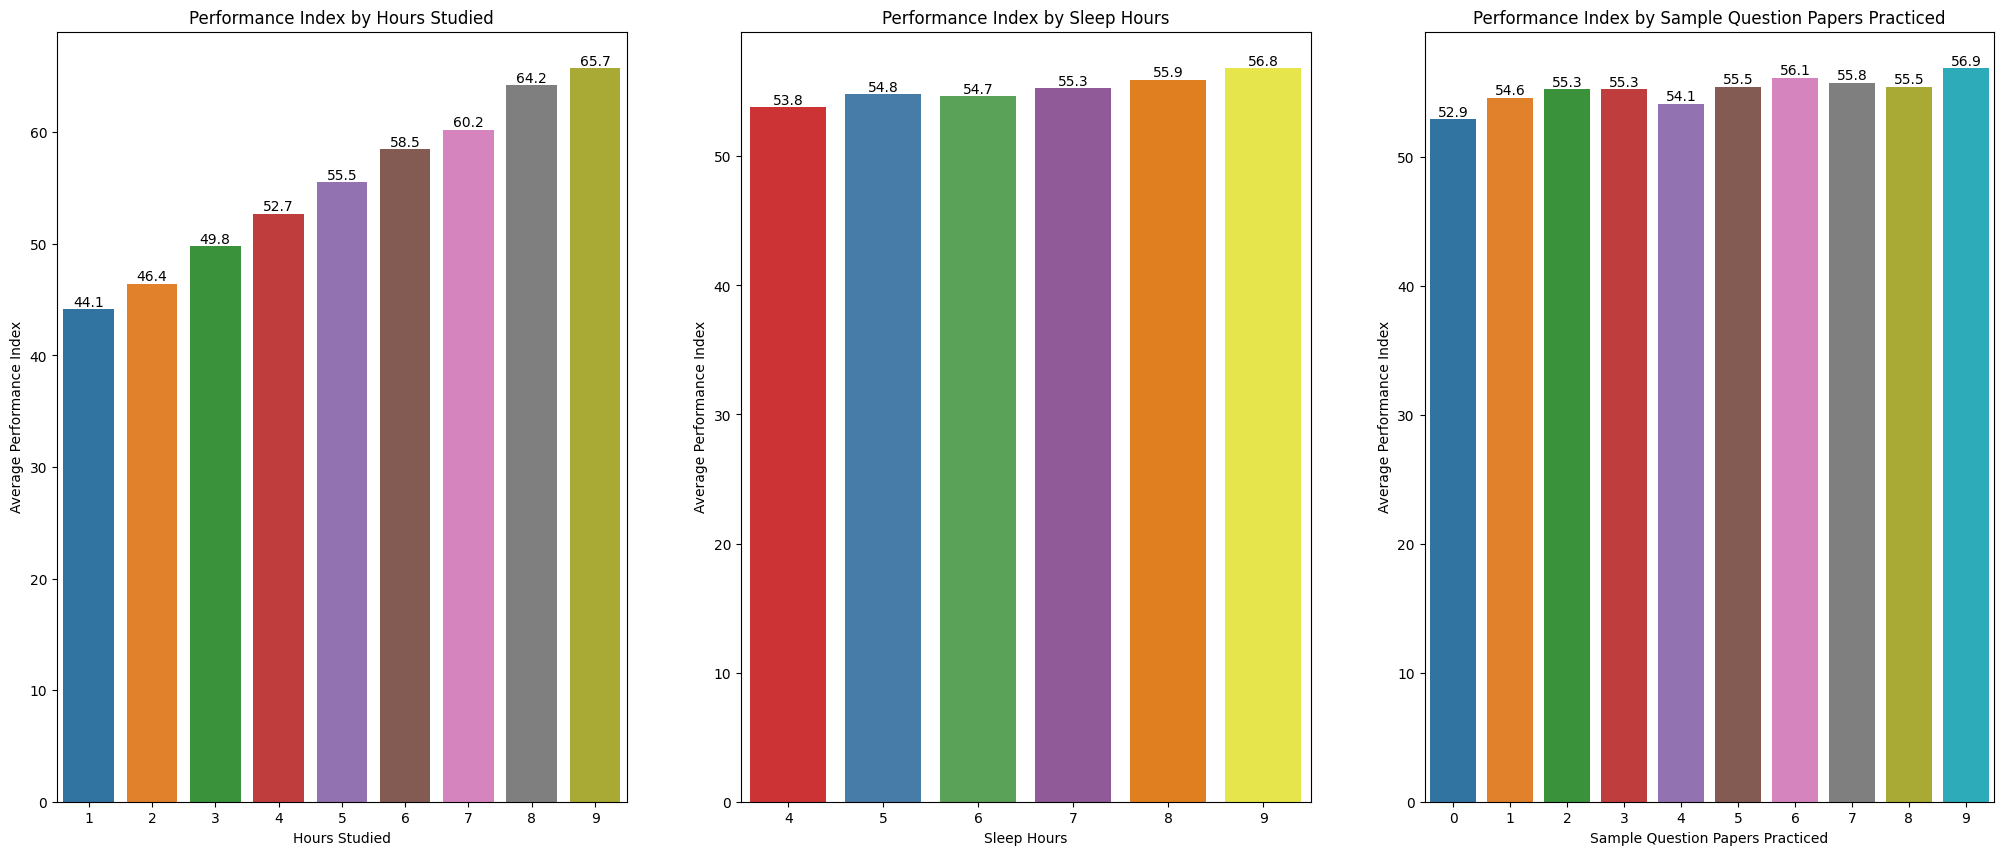

In [12]:
df_hrs_stud = data.groupby('Hours Studied')['Performance Index'].mean().reset_index()
df_hrs_stud.rename(columns={'Performance Index': 'Average Performance Index'}, inplace=True)
df_slp_hrs = data.groupby('Sleep Hours')['Performance Index'].mean().reset_index()
df_slp_hrs.rename(columns={'Performance Index': 'Average Performance Index'}, inplace=True)
df_sam_pap_prac = data.groupby('Sample Question Papers Practiced')['Performance Index'].mean().reset_index()
df_sam_pap_prac.rename(columns={'Performance Index': 'Average Performance Index'}, inplace=True)

palette_1 = sns.color_palette("tab10", 9)  # 'tab10' palette with 9 colors
palette_2 = sns.color_palette("Set1", 6)  # 'Set1' palette with 6 colors
palette_3 = sns.color_palette("tab10", 10)  # 'tab10' palette with 10 colors

plt.figure(figsize=(25,10))

plt.subplot(131)
plt.title("Performance Index by Hours Studied")
sns.barplot(data=df_hrs_stud, x='Hours Studied', y='Average Performance Index', palette=palette_1)
[plt.gca().bar_label(container, fmt='%.1f') for container in plt.gca().containers]

plt.subplot(132)
plt.title("Performance Index by Sleep Hours")
sns.barplot(data=df_slp_hrs, x='Sleep Hours', y='Average Performance Index', palette=palette_2)
[plt.gca().bar_label(container, fmt='%.1f') for container in plt.gca().containers]

plt.subplot(133)
plt.title("Performance Index by Sample Question Papers Practiced")
sns.barplot(data=df_sam_pap_prac, x='Sample Question Papers Practiced', y='Average Performance Index', palette=palette_3)
[plt.gca().bar_label(container, fmt='%.1f') for container in plt.gca().containers]
plt.show()

- **More hours** given to studies tends to **higher Performance Index**.
- A **good sleep hours of 8 or 9** have a good effect on **Performance Index**.
- For students that had practiced **6 and 9 Sample Question Papers has a good Performance Index** compared to other students. It is evident that solving Sample Question Papers had helped students to achieve good Performance Index.

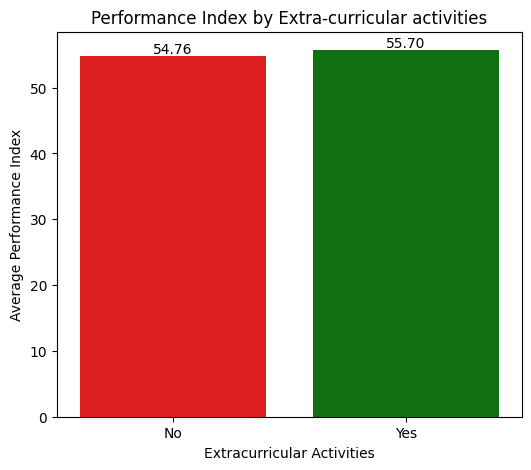

In [13]:
df_ext_curr_act = data.groupby('Extracurricular Activities')['Performance Index'].mean().reset_index()
df_ext_curr_act.rename(columns={'Performance Index': 'Average Performance Index'}, inplace=True)

custom_palette = ['#FF0000', '#008000'] # Red and Green

plt.figure(figsize=(6,5))
plt.title('Performance Index by Extra-curricular activities')
sns.barplot(data=df_ext_curr_act, x='Extracurricular Activities', y='Average Performance Index', palette=custom_palette)
[plt.gca().bar_label(container, fmt='%.2f') for container in plt.gca().containers]
plt.show()

**On an average, students involved in Extra-curricular activities are performing well.**

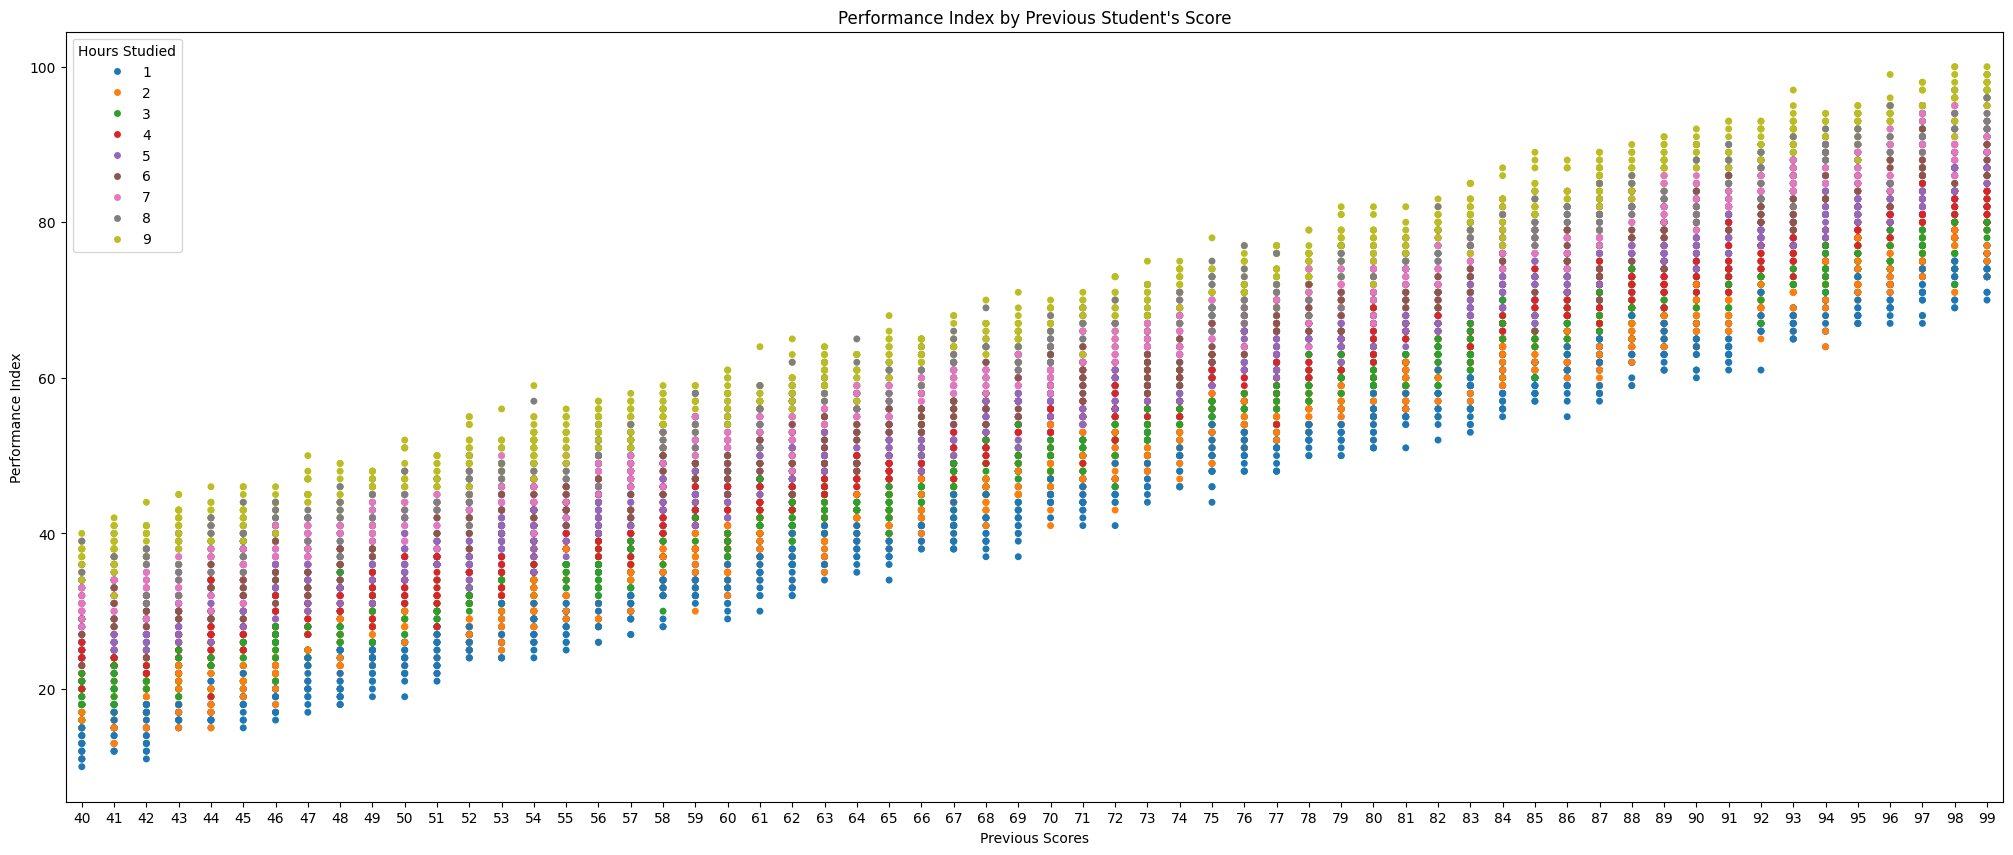

In [14]:
plt.figure(figsize=(25,10))
palette_1 = sns.color_palette("tab10", 9)

sns.stripplot(data=data, x='Previous Scores', y='Performance Index', hue='Hours Studied', palette=palette_1, jitter=False)
plt.title("Performance Index by Previous Student's Score")
plt.show()

- Seems a **positive correlation** between **Previous Scores and Perfomance Index**.
- **More Hours Studied** directly correspond to more Previous Scores and thus, **more Performance Index**.  

### 4.3 Multi-Variate Analysis

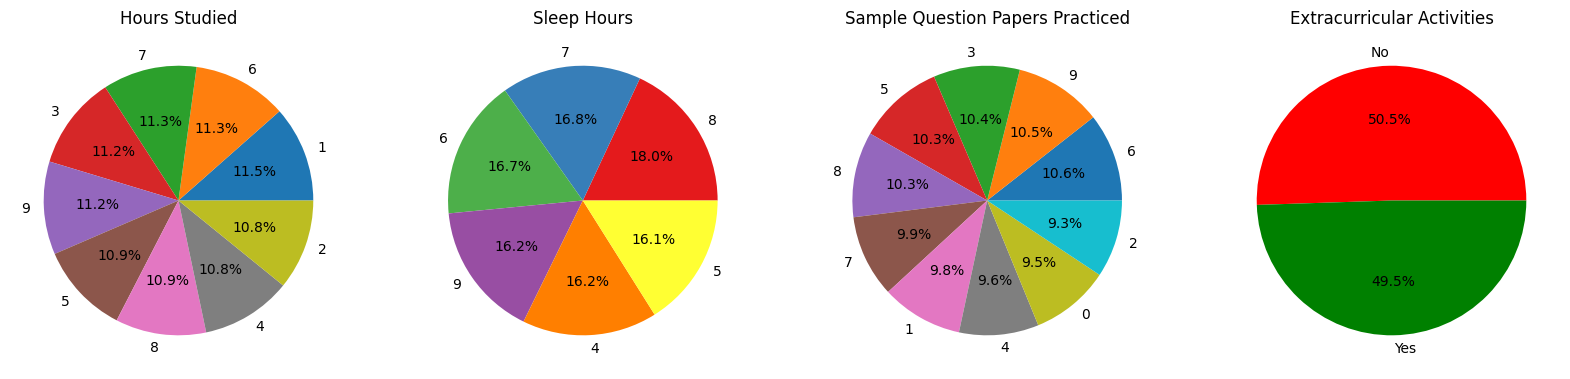

In [15]:
plt.figure(figsize=(20,10))

plt.subplot(141)
plt.title('Hours Studied')
size_1 = data['Hours Studied'].value_counts().values
labels_1 = data['Hours Studied'].value_counts().index
palette_1 = sns.color_palette("tab10", 9)

plt.pie(size_1, labels=labels_1, colors=palette_1, autopct='%.1f%%')
plt.axis('off')

plt.subplot(142)
plt.title('Sleep Hours')
size_2 = data['Sleep Hours'].value_counts().values
labels_2 = data['Sleep Hours'].value_counts().index
palette_2 = sns.color_palette("Set1", 6)

plt.pie(size_2, labels=labels_2, colors=palette_2, autopct='%.1f%%')
plt.axis('off')

plt.subplot(143)
plt.title('Sample Question Papers Practiced')
size_3 = data['Sample Question Papers Practiced'].value_counts().values
labels_3 = data['Sample Question Papers Practiced'].value_counts().index
palette_3 = sns.color_palette("tab10", 10)

plt.pie(size_3, labels=labels_3, colors=palette_3, autopct='%.1f%%')
plt.axis('off')

plt.subplot(144)
plt.title('Extracurricular Activities')
size_4 = data['Extracurricular Activities'].value_counts().values
labels_4 = data['Extracurricular Activities'].value_counts().index
palette_4 = ['#FF0000', '#008000']

plt.pie(size_4, labels=labels_4, colors=palette_4, autopct='%.1f%%')
plt.axis('off')

plt.show()

- Study Hours of 1 (11.5% students) is most prominent followed by 6, 7 and 9.
- 8 Hours of sleep is taken by most of the students (18.0%).
- 6 Sample Question Papers are mostly solved by the students (10.6%).
- Students are fairly distributed in terms of participation in Extra-curricular activities.

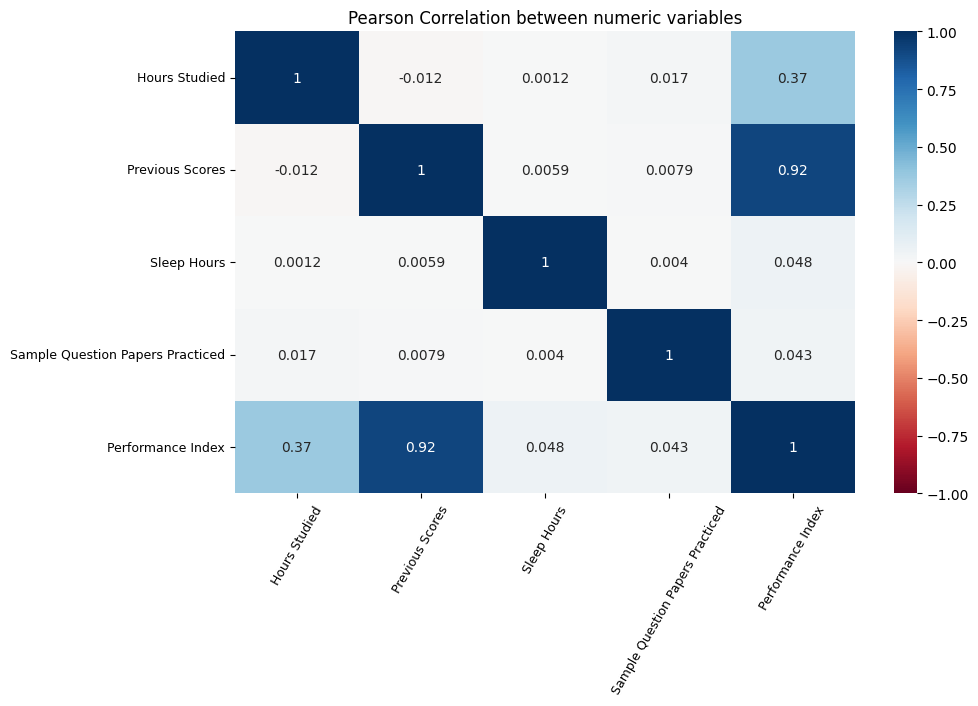

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap='RdBu')
plt.title("Pearson Correlation between numeric variables")
plt.xticks(rotation=60, fontsize=9)
plt.yticks(fontsize=9)
plt.show()

- **Previous Score is strongly in linear relation with Performance Index (r = 0.92)**.
- **Hours Studied is moderately related to Perfomance Index (r = 0.37)**.

### 4.4 Checking for Outliers

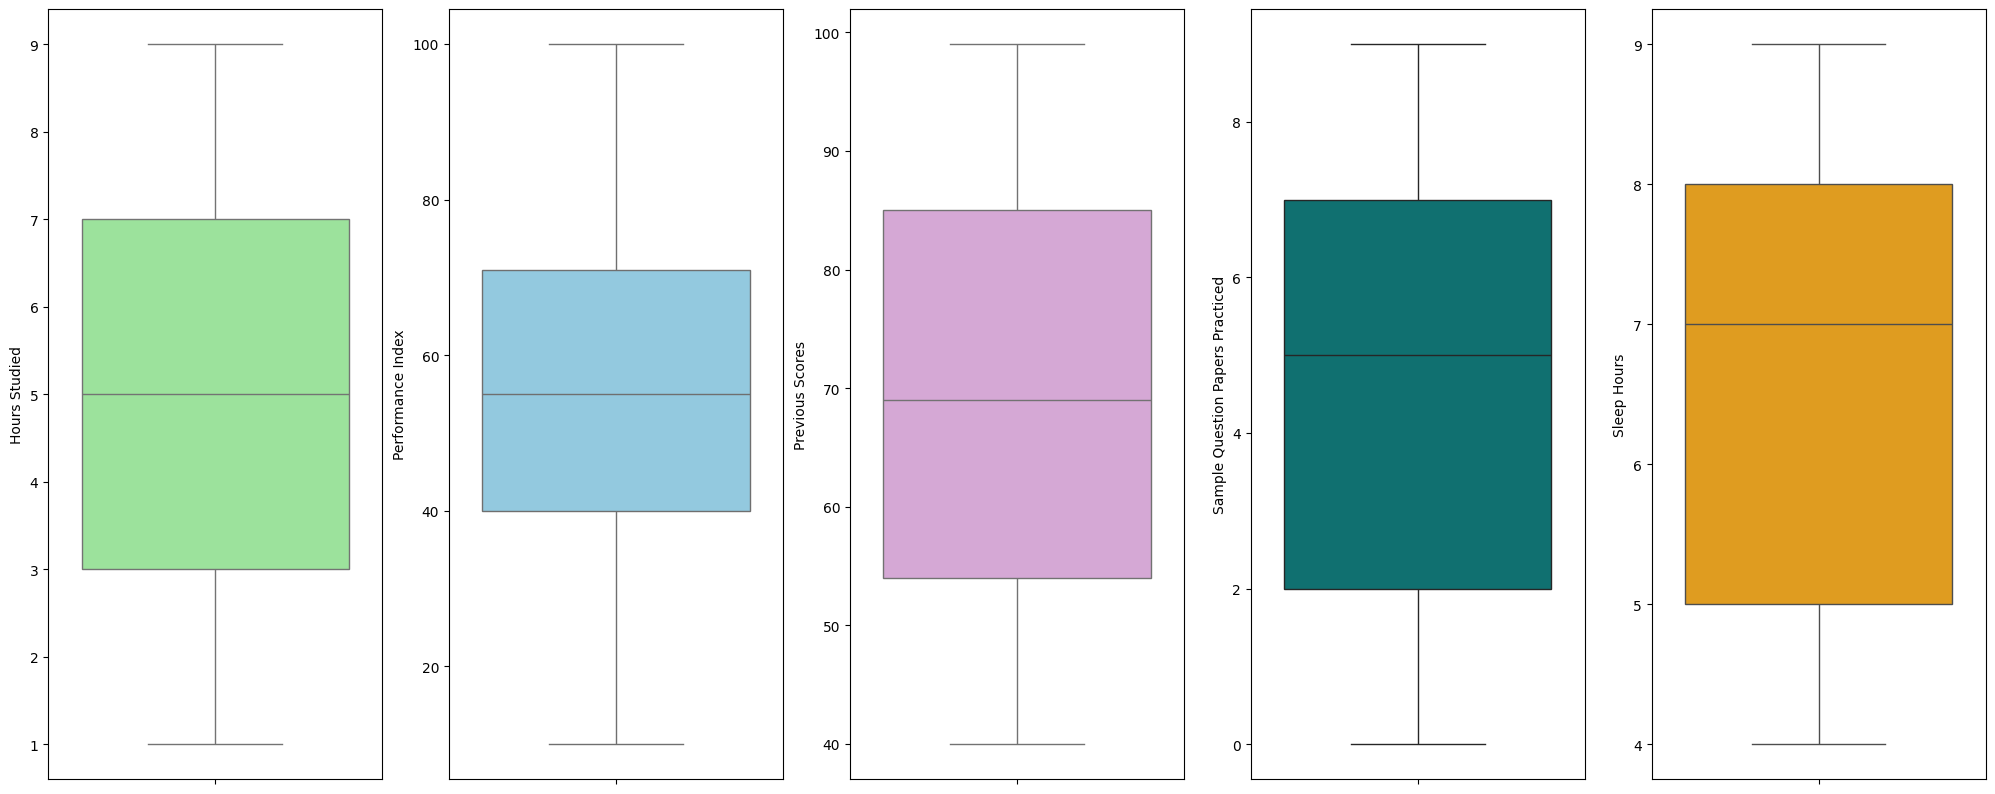

In [17]:
plt.figure(figsize=(25,10))

plt.subplot(151)
sns.boxplot(data['Hours Studied'], color='lightgreen')

plt.subplot(152)
sns.boxplot(data['Performance Index'], color='skyblue')

plt.subplot(153)
sns.boxplot(data['Previous Scores'], color='plum')

plt.subplot(154)
sns.boxplot(data['Sample Question Papers Practiced'], color='teal')

plt.subplot(155)
sns.boxplot(data['Sleep Hours'], color='orange')

plt.show()

**It seems there are no outliers for any of the features.** 

## Conclusion

- More hours given to studies tends to higher *Performance Index*.
- Previous Scores are strongly correlated to *Performance Index*.
- On an average, students involved in **Extra-curricular activities are performing well**.
- More sleep hours and more sample question papers solved by students have **some positive influence** on *Performance*.